# 02. Feature Engineering — 원본 `.mat`에서 Cell당 1행 만들기

**Day 2 Regression · 배터리 Cycle Life 예측**  
작성자: **U094 이수현** · 작성일: **2026-10-02**

> 목표: 실제 cycle 번호 기준의 초기 100 cycle만 사용해 미래 수명을 설명할 수 있는 Feature Table을 만든다.

이 노트북은 결과 CSV를 설명하는 문서가 아니라 **Feature Engineering의 주 실행본**이다. 원본 구조 확인, 유효값 필터, ΔQ(V), Cell 단위 집계, 품질검사, 고정 split과 누수 점검 코드가 모두 포함되어 있다.

- 빠른 검토: `REBUILD_FROM_RAW = False`로 Run All
- 원본부터 재현: `REBUILD_FROM_RAW = True` (7GB가 넘는 파일을 읽으므로 시간이 걸림)
- 개인 실험: 공식 결과를 덮어쓰지 않도록 `SAVE_REBUILT_TABLES = False` 유지

> **편집 주의:** 이 파일을 직접 보완한 뒤 `src/build_day2_notebooks.py`를 다시 실행하면 수동 변경이 덮어써진다. 앞으로 노트북을 주 작업본으로 사용할 때는 먼저 Git commit이나 별도 백업을 남긴다.

## 1. 환경과 데이터 계약

분석 단위는 cycle 행이 아니라 **Cell당 1행**이다. 같은 Cell의 cycle을 train과 validation에 나누면 동일 배터리 정보가 양쪽에 들어가는 누수가 생긴다.

- Summary Feature: 실제 cycle 2~100
- ΔQ(V): `Qdlin(cycle 100) − Qdlin(cycle 10)`
- Charging Feature: 시험 시작 전에 정해진 프로토콜
- 금지: cycle 100 이후 값, Knee, EOL, cycle_life 또는 이를 직접 암시하는 값

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Any
import hashlib
import json
import re
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

LOCAL_PACKAGES = ROOT / ".python_packages"
if LOCAL_PACKAGES.exists() and str(LOCAL_PACKAGES) not in sys.path:
    sys.path.insert(0, str(LOCAL_PACKAGES))

import h5py
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display
from scipy import stats
from sklearn.model_selection import train_test_split

DATA_DIR = ROOT / "data"
RESULT_DIR = ROOT / "results" / "day2"
FIGURE_DIR = ROOT / "figures" / "day2"
RANDOM_SEED = 20261002
BATCH_FILES = {
    "Batch 1": "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch 2": "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch 3": "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}

font_candidates = [
    Path("/Users/lsh/Library/Fonts/NotoSansKR-Regular.otf"),
    Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
    Path("/System/Library/Fonts/Supplemental/AppleGothic.ttf"),
]
font_path = next((path for path in font_candidates if path.exists()), None)
if font_path:
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

display(HTML("""
<style>
.jp-Notebook { max-width: 1180px; margin: auto; }
.jp-MarkdownOutput h1 { color:#173B5E; border-bottom:3px solid #1A9AA3; padding-bottom:.35rem; }
.jp-MarkdownOutput h2 { color:#173B5E; margin-top:2rem; }
.jp-MarkdownOutput h3 { color:#138A92; }
.jp-MarkdownOutput blockquote { border-left:5px solid #1A9AA3; background:#F1F8F8; padding:.75rem 1rem; }
.dataframe { font-size:13px; }
</style>
"""))

print("프로젝트 루트:", ROOT)
print("원본 데이터 폴더:", DATA_DIR)

프로젝트 루트: /Users/lsh/ess-battery-health
원본 데이터 폴더: /Users/lsh/ess-battery-health/data


## 2. 원본 MATLAB v7.3 구조 확인

파일 전체를 메모리에 올리지 않고 `h5py` 참조를 따라 필요한 Cell과 필드만 읽는다. 아래 코드는 Batch 1의 최상위 구조와 첫 Cell의 Summary 필드를 직접 확인한다.

In [2]:
sample_file = DATA_DIR / BATCH_FILES["Batch 1"]
with h5py.File(sample_file, "r") as handle:
    batch = handle["batch"]
    first_summary = handle[batch["summary"][0, 0]]
    structure = {
        "최상위 key": list(handle.keys()),
        "batch field": list(batch.keys()),
        "첫 Cell summary field": list(first_summary.keys()),
        "원본 Cell 수": int(batch["cycle_life"].shape[0]),
    }
for key, value in structure.items():
    print(f"{key}: {value}")

최상위 key: ['#refs#', '#subsystem#', 'batch', 'batch_date']
batch field: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
첫 Cell summary field: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
원본 Cell 수: 46


`cycle_life`, `summary`, `cycles`, `Vdlin`, `policy_readable`은 각 Cell을 가리키는 참조 배열이다. 따라서 단순한 표 읽기가 아니라 Cell 참조를 역참조해야 한다.

## 3. 원본 읽기와 Feature 계산 함수

아래는 실제 구현이다. `metric_features()`는 cycle 2~100만 필터링하고, `delta_q_statistics()`는 ΔQ 곡선을 모델에 넣을 수 있는 통계량으로 바꾼다.

In [3]:
@dataclass(frozen=True)
class Paths:
    root: Path
    data: Path
    results: Path
    figures: Path
    reports: Path

def make_paths(root: Path) -> Paths:
    paths = Paths(
        root=root,
        data=root / "data",
        results=root / "results" / "day2",
        figures=root / "figures" / "day2",
        reports=root / "reports",
    )
    paths.results.mkdir(parents=True, exist_ok=True)
    paths.figures.mkdir(parents=True, exist_ok=True)
    paths.reports.mkdir(parents=True, exist_ok=True)
    return paths

def flat(dataset: h5py.Dataset) -> np.ndarray:
    return np.asarray(dataset, dtype=float).reshape(-1)

def deref_scalar(handle: h5py.File, ref: Any) -> float:
    return float(np.asarray(handle[ref]).squeeze())

def decode_matlab_char(dataset: h5py.Dataset) -> str:
    values = np.asarray(dataset).reshape(-1)
    if values.dtype.kind in "ui":
        return "".join(chr(int(v)) for v in values if int(v) != 0)
    if values.dtype.kind == "S":
        return b"".join(values.tolist()).decode("utf-8", errors="replace")
    return str(values[0]) if len(values) else ""

def parse_policy(policy: str) -> dict[str, Any]:
    match = POLICY_PATTERN.search(policy)
    if match:
        return {
            "policy_parse_success": True,
            "policy_type": "2단계 정전류",
            "c_rate_stage1": float(match.group("c1")),
            "switch_soc_pct": float(match.group("soc")),
            "c_rate_stage2": float(match.group("c2")),
            "policy_new_structure": "newstructure" in policy.lower(),
            "policy_slow_cycle": "slowcycle" in policy.lower(),
        }
    match = VAR_POLICY_PATTERN.search(policy)
    if match:
        return {
            "policy_parse_success": True,
            "policy_type": "가변 충전",
            "c_rate_stage1": float(match.group("c1")),
            "switch_soc_pct": np.nan,
            "c_rate_stage2": np.nan,
            "policy_new_structure": False,
            "policy_slow_cycle": False,
        }
    return {
        "policy_parse_success": False,
        "policy_type": "기타",
        "c_rate_stage1": np.nan,
        "switch_soc_pct": np.nan,
        "c_rate_stage2": np.nan,
        "policy_new_structure": "newstructure" in policy.lower(),
        "policy_slow_cycle": "slowcycle" in policy.lower(),
    }

def valid_metric_mask(name: str, values: np.ndarray) -> np.ndarray:
    mask = np.isfinite(values)
    if name in {"qd", "qc"}:
        mask &= (values > 0.2) & (values < 2.0)
    elif name == "ir":
        mask &= (values > 0.001) & (values < 0.2)
    elif name in {"tavg", "tmax", "tmin"}:
        mask &= (values > 5.0) & (values < 80.0)
    elif name == "chargetime":
        mask &= (values > 0.1) & (values < 120.0)
    return mask

def metric_features(name: str, cycles: np.ndarray, values: np.ndarray) -> dict[str, float]:
    mask = (cycles >= 2) & (cycles <= 100) & valid_metric_mask(name, values)
    x, y = cycles[mask], values[mask]
    result = {
        f"{name}_n": float(len(y)),
        f"{name}_mean": np.nan,
        f"{name}_std": np.nan,
        f"{name}_median": np.nan,
        f"{name}_min": np.nan,
        f"{name}_max": np.nan,
        f"{name}_delta": np.nan,
        f"{name}_slope": np.nan,
    }
    if len(y) == 0:
        return result
    order = np.argsort(x)
    x, y = x[order], y[order]
    result.update(
        {
            f"{name}_mean": float(np.mean(y)),
            f"{name}_std": float(np.std(y, ddof=1)) if len(y) > 1 else 0.0,
            f"{name}_median": float(np.median(y)),
            f"{name}_min": float(np.min(y)),
            f"{name}_max": float(np.max(y)),
            f"{name}_delta": float(y[-1] - y[0]),
            f"{name}_slope": float(np.polyfit(x, y, 1)[0]) if len(y) >= 3 else np.nan,
        }
    )
    return result

def delta_q_statistics(voltage: np.ndarray, delta_q: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(voltage) & np.isfinite(delta_q)
    v, dq = voltage[mask], delta_q[mask]
    if len(dq) < 20:
        return {}
    order = np.argsort(v)
    v_sorted, dq_sorted = v[order], dq[order]
    variance = float(np.var(dq, ddof=1))
    return {
        "delta_q_n": float(len(dq)),
        "delta_q_min": float(np.min(dq)),
        "delta_q_max": float(np.max(dq)),
        "delta_q_mean": float(np.mean(dq)),
        "delta_q_std": float(np.std(dq, ddof=1)),
        "delta_q_var": variance,
        "delta_q_log10_var": float(np.log10(variance + 1e-12)),
        "delta_q_q05": float(np.quantile(dq, 0.05)),
        "delta_q_q25": float(np.quantile(dq, 0.25)),
        "delta_q_q50": float(np.quantile(dq, 0.50)),
        "delta_q_q75": float(np.quantile(dq, 0.75)),
        "delta_q_q95": float(np.quantile(dq, 0.95)),
        "delta_q_iqr": float(np.quantile(dq, 0.75) - np.quantile(dq, 0.25)),
        "delta_q_min_voltage": float(v[np.argmin(dq)]),
        "delta_q_max_voltage": float(v[np.argmax(dq)]),
        "delta_q_area": float(np.trapezoid(dq_sorted, v_sorted)),
        "delta_q_abs_area": float(np.trapezoid(np.abs(dq_sorted), v_sorted)),
        "delta_q_l1": float(np.mean(np.abs(dq))),
        "delta_q_l2": float(np.sqrt(np.mean(np.square(dq)))),
        "delta_q_skew": float(stats.skew(dq, bias=False, nan_policy="omit")),
        "delta_q_kurtosis": float(stats.kurtosis(dq, bias=False, nan_policy="omit")),
    }

def life_group(value: float) -> str:
    if not np.isfinite(value):
        return "Target 결측"
    if value < 500:
        return "단수명(<500)"
    if value > 1000:
        return "장수명(>1,000)"
    return "중간수명(500~1,000)"

def sha256_file(path: Path, chunk_size: int = 16 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        while chunk := stream.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

읽을 때는 다음을 확인한다.

1. `valid_metric_mask()`가 물리적으로 말이 되지 않는 0값과 극단값을 제거한다.
2. `metric_features()`가 평균·표준편차·변화량·기울기를 같은 규칙으로 계산한다.
3. `delta_q_statistics()`가 전압을 정렬한 후 분산, IQR, 최솟값, 절대면적을 계산한다.
4. 분산에는 `1e-12`를 더한 뒤 로그를 취해 0의 로그 문제를 피한다.

## 4. 전체 Cell 추출 로직

이 함수가 세 Batch를 순회하면서 실제 cycle 번호를 찾고 Cell당 하나의 `record`를 만든다. 배열의 10번째·100번째 위치가 아니라 `cycle_to_index`에서 실제 10과 100을 찾는 부분이 핵심이다.

In [4]:
def extract_raw_features(paths: Paths) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    metric_map = {
        "qd": "QDischarge",
        "qc": "QCharge",
        "ir": "IR",
        "tavg": "Tavg",
        "tmax": "Tmax",
        "tmin": "Tmin",
        "chargetime": "chargetime",
    }
    feature_rows: list[dict[str, Any]] = []
    quality_rows: list[dict[str, Any]] = []
    file_rows: list[dict[str, Any]] = []

    for batch_name, filename in BATCH_FILES.items():
        file_path = paths.data / filename
        if not file_path.exists():
            raise FileNotFoundError(file_path)
        print(f"[Gate 1] 원본 추출: {batch_name} / {filename}", flush=True)
        file_rows.append(
            {
                "batch": batch_name,
                "filename": filename,
                "size_bytes": file_path.stat().st_size,
                "sha256": sha256_file(file_path),
            }
        )
        with h5py.File(file_path, "r") as handle:
            batch = handle["batch"]
            n_cells = int(batch["cycle_life"].shape[0])
            for cell_index in range(n_cells):
                global_id = f"{batch_name.replace(' ', '')}_{cell_index:03d}"
                cycle_life = deref_scalar(handle, batch["cycle_life"][cell_index, 0])
                policy = decode_matlab_char(handle[batch["policy_readable"][cell_index, 0]])
                policy_info = parse_policy(policy)
                summary = handle[batch["summary"][cell_index, 0]]
                arrays = {"cycle": flat(summary["cycle"])}
                arrays.update({name: flat(summary[field]) for name, field in metric_map.items()})
                lengths = {name: len(values) for name, values in arrays.items()}
                common_length = min(lengths.values())
                arrays = {name: values[:common_length] for name, values in arrays.items()}
                cycles = arrays["cycle"]
                cycle_to_index = {
                    int(round(cycle)): idx
                    for idx, cycle in enumerate(cycles)
                    if np.isfinite(cycle)
                }

                record: dict[str, Any] = {
                    "batch": batch_name,
                    "cell_index": cell_index,
                    "global_cell_id": global_id,
                    "cycle_life": cycle_life,
                    "target_available": bool(np.isfinite(cycle_life)),
                    "life_group": life_group(cycle_life),
                    "charging_policy": policy,
                    **policy_info,
                }
                for metric in metric_map:
                    record.update(metric_features(metric, cycles, arrays[metric]))

                early_mask = (cycles >= 2) & (cycles <= 100)
                temp_range = arrays["tmax"] - arrays["tmin"]
                temp_valid = early_mask & np.isfinite(temp_range) & (temp_range >= 0) & (temp_range < 50)
                record["temperature_range_mean"] = (
                    float(np.mean(temp_range[temp_valid])) if temp_valid.any() else np.nan
                )
                ratio_mask = (
                    early_mask
                    & valid_metric_mask("qd", arrays["qd"])
                    & valid_metric_mask("qc", arrays["qc"])
                    & (arrays["qc"] != 0)
                )
                record["coulombic_efficiency_mean"] = (
                    float(np.mean(arrays["qd"][ratio_mask] / arrays["qc"][ratio_mask]))
                    if ratio_mask.any()
                    else np.nan
                )

                has_10, has_100 = 10 in cycle_to_index, 100 in cycle_to_index
                delta_valid = False
                delta_reason = "cycle 10 또는 100 없음"
                delta_length = 0
                cycles_group = handle[batch["cycles"][cell_index, 0]]
                qdlin_refs = cycles_group["Qdlin"]
                cycles_object_length = int(qdlin_refs.shape[0])
                if has_10 and has_100:
                    idx10, idx100 = cycle_to_index[10], cycle_to_index[100]
                    if idx10 < cycles_object_length and idx100 < cycles_object_length:
                        try:
                            voltage = flat(handle[batch["Vdlin"][cell_index, 0]])
                            q10_raw = np.asarray(handle[qdlin_refs[idx10, 0]]).reshape(-1)
                            q100_raw = np.asarray(handle[qdlin_refs[idx100, 0]]).reshape(-1)
                            if (
                                q10_raw.dtype.kind == "f"
                                and q100_raw.dtype.kind == "f"
                                and len(voltage) == len(q10_raw) == len(q100_raw)
                                and len(voltage) >= 20
                            ):
                                delta_q = q100_raw.astype(float) - q10_raw.astype(float)
                                delta_stats = delta_q_statistics(voltage, delta_q)
                                delta_length = int(len(voltage))
                                if delta_stats:
                                    record.update(delta_stats)
                                    delta_valid = True
                                    delta_reason = "계산 완료"
                                else:
                                    delta_reason = "유효 ΔQ(V) 포인트 부족"
                            else:
                                delta_reason = "Qdlin/Vdlin 길이 또는 자료형 불일치"
                        except (KeyError, ValueError, TypeError, OSError) as exc:
                            delta_reason = f"Qdlin 읽기 실패: {type(exc).__name__}"

                record["delta_q_available"] = delta_valid
                record["delta_q_reason"] = delta_reason
                feature_rows.append(record)

                first_cycle_mask = cycles == 1
                first_all_zero = False
                if first_cycle_mask.any():
                    first_idx = int(np.flatnonzero(first_cycle_mask)[0])
                    first_all_zero = all(
                        np.isclose(arrays[m][first_idx], 0.0, equal_nan=False)
                        for m in metric_map
                    )
                quality_rows.append(
                    {
                        "batch": batch_name,
                        "global_cell_id": global_id,
                        "cycle_life": cycle_life,
                        "target_available": bool(np.isfinite(cycle_life)),
                        "summary_length": common_length,
                        "summary_fields_same_length": len(set(lengths.values())) == 1,
                        "summary_cycles_match_objects": common_length == cycles_object_length,
                        "summary_cycles_strictly_increasing": bool(np.all(np.diff(cycles) > 0)),
                        "duplicate_cycle_count": int(pd.Series(cycles).duplicated().sum()),
                        "summary_min_cycle": float(np.nanmin(cycles)) if len(cycles) else np.nan,
                        "summary_max_cycle": float(np.nanmax(cycles)) if len(cycles) else np.nan,
                        "cycle_10_available": has_10,
                        "cycle_100_available": has_100,
                        "first_cycle_all_zero": first_all_zero,
                        "early_qd_valid_count": int((early_mask & valid_metric_mask("qd", arrays["qd"])).sum()),
                        "early_ir_valid_count": int((early_mask & valid_metric_mask("ir", arrays["ir"])).sum()),
                        "early_temp_valid_count": int((early_mask & valid_metric_mask("tavg", arrays["tavg"])).sum()),
                        "delta_q_available": delta_valid,
                        "delta_q_point_count": delta_length,
                        "delta_q_reason": delta_reason,
                        "policy_parse_success": bool(policy_info["policy_parse_success"]),
                        "included_for_supervised": bool(np.isfinite(cycle_life)),
                        "exclusion_reason": "" if np.isfinite(cycle_life) else "cycle_life 결측",
                    }
                )

    features = pd.DataFrame(feature_rows)
    quality = pd.DataFrame(quality_rows)
    files = pd.DataFrame(file_rows)
    if not features["global_cell_id"].is_unique:
        raise AssertionError("global_cell_id가 유일하지 않습니다.")
    return features, quality, files

### 품질 요약·고정 split·Feature Manifest 함수

원본 재계산 직후 사용할 품질 요약 함수도 먼저 정의한다. Target 결측을 따로 기록하고 Batch 1만 development/hold-out으로 나누며, 모든 Feature의 출처·cycle 범위·공식·단위를 문서화한다.

In [5]:
def build_quality_summary(features: pd.DataFrame, quality: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for batch, group in quality.groupby("batch", sort=False):
        rows.append(
            {
                "batch": batch,
                "raw_cells": len(group),
                "target_available": int(group["target_available"].sum()),
                "cycle_10_available": int(group["cycle_10_available"].sum()),
                "cycle_100_available": int(group["cycle_100_available"].sum()),
                "delta_q_available": int(group["delta_q_available"].sum()),
                "policy_parse_success": int(group["policy_parse_success"].sum()),
                "supervised_rows": int(group["included_for_supervised"].sum()),
                "delta_q_availability_pct": 100 * group["delta_q_available"].mean(),
                "target_availability_pct": 100 * group["target_available"].mean(),
            }
        )
    return pd.DataFrame(rows)

def make_split_assignment(features: pd.DataFrame) -> pd.DataFrame:
    assignment = features[
        ["batch", "global_cell_id", "cycle_life", "target_available", "life_group"]
    ].copy()
    assignment["split"] = "excluded_target_missing"
    batch1 = assignment[(assignment["batch"] == "Batch 1") & assignment["target_available"]].copy()
    strata = pd.qcut(batch1["cycle_life"], q=3, labels=["낮음", "중간", "높음"], duplicates="drop")
    stratify = strata if strata.nunique() == 3 and strata.value_counts().min() >= 2 else None
    dev_ids, holdout_ids = train_test_split(
        batch1["global_cell_id"],
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=stratify,
    )
    assignment.loc[assignment["global_cell_id"].isin(dev_ids), "split"] = "development"
    assignment.loc[assignment["global_cell_id"].isin(holdout_ids), "split"] = "holdout"
    assignment.loc[(assignment["batch"] == "Batch 2") & assignment["target_available"], "split"] = "external_test"
    assignment.loc[(assignment["batch"] == "Batch 3") & assignment["target_available"], "split"] = "additional_test"
    assignment["split_seed"] = RANDOM_SEED
    if set(dev_ids) & set(holdout_ids):
        raise AssertionError("Development와 hold-out Cell이 겹칩니다.")
    return assignment.sort_values(["batch", "global_cell_id"]).reset_index(drop=True)

def make_feature_manifest() -> pd.DataFrame:
    rows = [
        ("qd_mean", "Capacity", "summary.QDischarge", "2~100", "mean(valid QD)", "Ah", "fold median+flag", "F0", "초기 용량 기준"),
        ("qd_slope", "Capacity", "summary.QDischarge", "2~100", "slope(QD~cycle)", "Ah/cycle", "fold median+flag", "F0", "초기 용량 변화"),
        ("delta_q_log10_var", "DeltaQ", "cycles.Qdlin", "10,100", "log10(var(Q100-Q10)+1e-12)", "log10(Ah²)", "fold median+flag", "F1", "세 Batch에서 강하고 일관된 관계"),
        ("delta_q_iqr", "DeltaQ alternative", "cycles.Qdlin", "10,100", "Q75(ΔQ)-Q25(ΔQ)", "Ah", "fold median+flag", "Screen", "이상값에 강한 대체 후보"),
        ("delta_q_min", "DeltaQ alternative", "cycles.Qdlin", "10,100", "min(ΔQ)", "Ah", "fold median+flag", "Screen", "국소 변화 대체 후보"),
        ("delta_q_abs_area", "DeltaQ alternative", "cycles.Qdlin", "10,100", "integral(abs(ΔQ))dV", "Ah·V", "fold median+flag", "Screen", "전압 전구간 변화 대체 후보"),
        ("ir_mean", "Sensor", "summary.IR", "2~100", "mean(valid IR)", "Ω", "fold median+flag", "F3", "저항 수준 대표"),
        ("tavg_mean", "Sensor", "summary.Tavg", "2~100", "mean(valid Tavg)", "°C", "fold median+flag", "F3", "온도 수준 대표"),
        ("chargetime_mean", "Sensor", "summary.chargetime", "2~100", "mean(valid charge time)", "min", "fold median+flag", "F3", "충전시간 대표"),
        ("c_rate_stage1", "Charging", "policy_readable", "사전 설정", "parsed first-stage C-rate", "C", "fold median+flag", "F4", "연속형 충전조건"),
        ("switch_soc_pct", "Charging", "policy_readable", "사전 설정", "parsed switching SOC", "%", "fold median+flag", "F4", "연속형 충전조건"),
        ("c_rate_stage2", "Charging", "policy_readable", "사전 설정", "parsed second-stage C-rate", "C", "fold median+flag", "F4", "연속형 충전조건"),
        ("policy_new_structure", "Charging", "policy_readable", "사전 설정", "newstructure flag", "bool", "none", "F4", "Cell 구조 보조정보"),
        ("policy_slow_cycle", "Charging", "policy_readable", "사전 설정", "slowcycle flag", "bool", "none", "F4", "정책 보조정보"),
    ]
    columns = [
        "feature_name", "feature_group", "source_field", "cycle_range", "formula", "unit",
        "missing_rule", "ablation_stage", "day1_evidence",
    ]
    manifest = pd.DataFrame(rows, columns=columns)
    manifest["leakage_check"] = "cycle 100 이내 또는 사전 정책"
    manifest["final_selected"] = False
    return manifest

def validate_against_day1(features: pd.DataFrame, paths: Paths) -> pd.DataFrame:
    reference_path = paths.root / "results" / "day1" / "early_features.csv"
    if not reference_path.exists():
        return pd.DataFrame([{"check": "Day 1 reference", "status": "미실행", "detail": "파일 없음"}])
    reference = pd.read_csv(reference_path)
    common = sorted(set(features["global_cell_id"]) & set(reference["global_cell_id"]))
    columns = [
        "qd_mean", "qd_slope", "ir_mean", "tavg_mean", "chargetime_mean",
        "delta_q_log10_var", "delta_q_iqr", "delta_q_min", "delta_q_abs_area",
    ]
    merged = features.set_index("global_cell_id").loc[common].join(
        reference.set_index("global_cell_id")[columns], rsuffix="_day1"
    )
    rows = []
    for column in columns:
        left = pd.to_numeric(merged[column], errors="coerce")
        right = pd.to_numeric(merged[f"{column}_day1"], errors="coerce")
        mask = left.notna() & right.notna()
        max_diff = float(np.max(np.abs(left[mask] - right[mask]))) if mask.any() else np.nan
        rows.append(
            {
                "check": column,
                "matched_cells": int(mask.sum()),
                "max_abs_difference": max_diff,
                "status": "통과" if (not np.isfinite(max_diff) or max_diff < 1e-10) else "불일치",
                "detail": "원본 .mat 재추출값과 Day 1 결과 비교",
            }
        )
    result = pd.DataFrame(rows)
    if (result["status"] == "불일치").any():
        raise AssertionError("Day 1 Feature 재현 검증에 실패했습니다.")
    return result

## 5. 원본 재계산 또는 저장 결과 불러오기

전체 로직은 위에 공개되어 있다. 기본 Run All에서는 동일 코드로 이미 생성한 표를 읽어 시간을 절약한다. 원본 재현이 필요하면 첫 번째 스위치를 `True`로 바꾼다.

In [6]:
REBUILD_FROM_RAW = False
SAVE_REBUILT_TABLES = False

paths = make_paths(ROOT)
if REBUILD_FROM_RAW:
    feature_table, quality_detail, file_checks = extract_raw_features(paths)
    quality_summary = build_quality_summary(feature_table, quality_detail)
    if SAVE_REBUILT_TABLES:
        feature_table.to_csv(RESULT_DIR / "feature_table.csv", index=False, encoding="utf-8-sig")
        quality_detail.to_csv(RESULT_DIR / "delta_q_validation.csv", index=False, encoding="utf-8-sig")
        quality_summary.to_csv(RESULT_DIR / "data_quality_summary.csv", index=False, encoding="utf-8-sig")
        file_checks.to_csv(RESULT_DIR / "data_file_checksums.csv", index=False, encoding="utf-8-sig")
else:
    feature_table = pd.read_csv(RESULT_DIR / "feature_table.csv")
    quality_detail = pd.read_csv(RESULT_DIR / "delta_q_validation.csv")
    quality_summary = pd.read_csv(RESULT_DIR / "data_quality_summary.csv")
    file_checks = pd.read_csv(RESULT_DIR / "data_file_checksums.csv")

print(f"Feature Table: {feature_table.shape[0]}행 × {feature_table.shape[1]}열")
print(f"고유 Cell: {feature_table['global_cell_id'].nunique()}개")
display(feature_table[[
    "batch", "global_cell_id", "cycle_life", "qd_mean", "qd_slope",
    "delta_q_log10_var", "delta_q_iqr", "ir_mean", "tavg_mean",
    "c_rate_stage1", "switch_soc_pct"
]].head())

Feature Table: 139행 × 95열
고유 Cell: 139개


,batch,global_cell_id,cycle_life,qd_mean,qd_slope,delta_q_log10_var,delta_q_iqr,ir_mean,tavg_mean,c_rate_stage1,switch_soc_pct
0,Batch 1,Batch1_000,"1,190.0000",1.0806,-0.0002,-5.0144,0.0060,0.0166,31.6037,3.6000,80.0000
1,Batch 1,Batch1_001,"1,179.0000",1.0812,0.0000,-5.0135,0.0055,0.0169,31.3303,3.6000,80.0000
2,Batch 1,Batch1_002,"1,177.0000",1.0854,0.0000,-4.7366,0.0063,0.0168,31.4796,3.6000,80.0000
3,Batch 1,Batch1_003,"1,226.0000",1.0849,0.0000,-4.4422,0.0098,0.0163,29.9422,4.0000,80.0000
4,Batch 1,Batch1_004,"1,227.0000",1.0828,0.0000,-4.6473,0.0086,0.0167,31.4489,4.0000,80.0000


## 6. ΔQ(V)를 한 Cell에서 직접 확인

$$\Delta Q(V)=Q_{100}(V)-Q_{10}(V)$$

아래 코드는 원본의 실제 cycle 번호로 두 곡선을 찾아 직접 뺀다. 왼쪽은 두 Q(V) 곡선, 오른쪽은 그 차이다.

/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1673352593.py:36: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1673352593.py:36: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1673352593.py:36: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1673352593.py:36: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1673352593.py:36: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf9

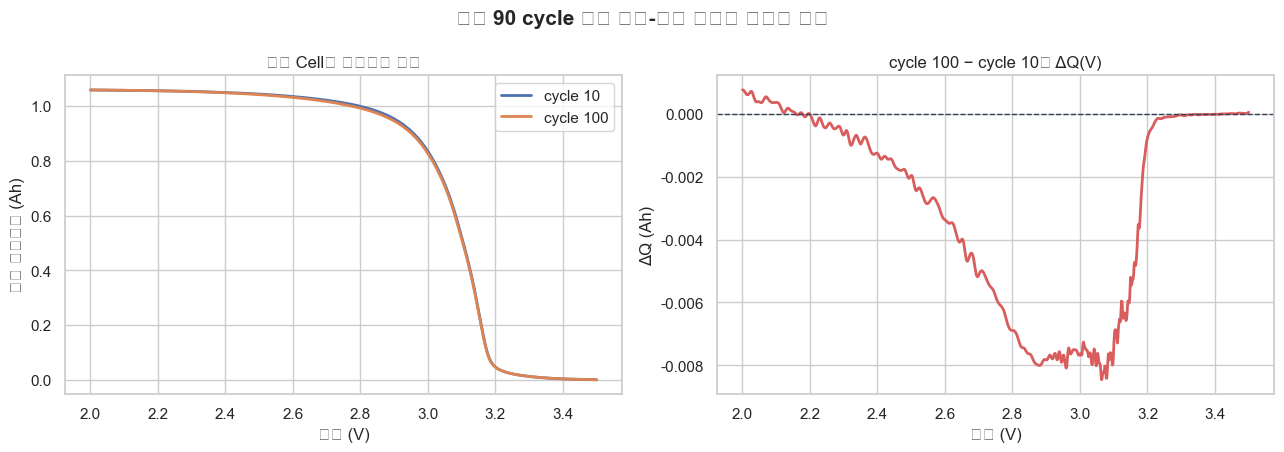

,값
delta_q_log10_var,-5.0144
delta_q_iqr,0.0060
delta_q_min,-0.0085
delta_q_abs_area,0.0044


In [7]:
def load_delta_q_curve(file_path: Path, cell_index: int) -> pd.DataFrame:
    """원본 한 Cell에서 실제 cycle 10·100의 Qdlin과 ΔQ를 반환한다."""
    with h5py.File(file_path, "r") as handle:
        batch = handle["batch"]
        summary = handle[batch["summary"][cell_index, 0]]
        cycles = flat(summary["cycle"])
        cycle_to_index = {
            int(round(cycle)): idx for idx, cycle in enumerate(cycles) if np.isfinite(cycle)
        }
        if 10 not in cycle_to_index or 100 not in cycle_to_index:
            raise ValueError("cycle 10 또는 100이 없습니다.")
        curves = handle[batch["cycles"][cell_index, 0]]["Qdlin"]
        idx10, idx100 = cycle_to_index[10], cycle_to_index[100]
        voltage = flat(handle[batch["Vdlin"][cell_index, 0]])
        q10 = flat(handle[curves[idx10, 0]])
        q100 = flat(handle[curves[idx100, 0]])
    if not (len(voltage) == len(q10) == len(q100)):
        raise ValueError("Vdlin과 Qdlin 길이가 다릅니다.")
    return pd.DataFrame({
        "전압": voltage, "cycle 10 Qdlin": q10,
        "cycle 100 Qdlin": q100, "ΔQ": q100 - q10,
    }).dropna()

dq_example = load_delta_q_curve(DATA_DIR / BATCH_FILES["Batch 1"], cell_index=0)
example_stats = delta_q_statistics(dq_example["전압"].to_numpy(), dq_example["ΔQ"].to_numpy())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(dq_example["전압"], dq_example["cycle 10 Qdlin"], label="cycle 10", lw=2)
axes[0].plot(dq_example["전압"], dq_example["cycle 100 Qdlin"], label="cycle 100", lw=2)
axes[0].set(title="동일 Cell의 방전용량 곡선", xlabel="전압 (V)", ylabel="누적 방전용량 (Ah)")
axes[0].legend()
axes[1].plot(dq_example["전압"], dq_example["ΔQ"], color="#D95D5D", lw=2)
axes[1].axhline(0, color="#334155", ls="--", lw=1)
axes[1].set(title="cycle 100 − cycle 10의 ΔQ(V)", xlabel="전압 (V)", ylabel="ΔQ (Ah)")
fig.suptitle("초기 90 cycle 동안 전압-용량 곡선이 이동한 정도", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

display(pd.Series({
    "delta_q_log10_var": example_stats["delta_q_log10_var"],
    "delta_q_iqr": example_stats["delta_q_iqr"],
    "delta_q_min": example_stats["delta_q_min"],
    "delta_q_abs_area": example_stats["delta_q_abs_area"],
}).to_frame("값"))

ΔQ 곡선 전체를 넣으면 작은 표본에 비해 변수가 너무 많아진다. 곡선을 대표 통계량으로 압축하고, 어느 하나를 Core로 쓸지는 Batch 1 development CV에서만 결정한다.

## 7. 품질 요약·고정 split·Feature Manifest 함수

앞에서 정의한 함수를 실제 Feature Table에 적용하고 저장 결과와 일치하는지 검증한다.

In [8]:
quality_summary_live = build_quality_summary(feature_table, quality_detail)
display(quality_summary_live)
assert len(feature_table) == 139
assert feature_table["global_cell_id"].is_unique
assert quality_detail["cycle_10_available"].all()
assert quality_detail["cycle_100_available"].all()
assert quality_detail["delta_q_available"].all()
print("품질검사 통과: 139개 Cell 모두 cycle 10·100과 ΔQ 계산 가능")

,batch,raw_cells,target_available,cycle_10_available,cycle_100_available,delta_q_available,policy_parse_success,supervised_rows,delta_q_availability_pct,target_availability_pct
0,Batch 1,46,46,46,46,46,46,46,100.0000,100.0000
1,Batch 2,47,39,47,47,47,47,39,100.0000,82.9787
2,Batch 3,46,44,46,46,46,46,44,100.0000,95.6522


품질검사 통과: 139개 Cell 모두 cycle 10·100과 ΔQ 계산 가능


Target이 없는 Cell은 Feature 계산 실패가 아니라 지도학습 정답이 없다는 뜻이다. 관측 종료 cycle로 Target을 대체하지 않고 supervised 평가에서만 제외한다.

In [9]:
split_live = make_split_assignment(feature_table)
split_saved = pd.read_csv(RESULT_DIR / "split_assignment.csv")
split_check = split_live[["global_cell_id", "split"]].merge(
    split_saved[["global_cell_id", "split"]], on="global_cell_id", suffixes=("_재계산", "_저장")
)
assert (split_check["split_재계산"] == split_check["split_저장"]).all()
display(split_live.groupby(["batch", "split"], as_index=False).agg(
    Cell_수=("global_cell_id", "size"), 평균_수명=("cycle_life", "mean")
).round(1))
print("고정 split 재현 통과 · seed =", RANDOM_SEED)

,batch,split,Cell_수,평균_수명
0,Batch 1,development,36,857.6000
1,Batch 1,holdout,10,798.4000
2,Batch 2,excluded_target_missing,8,NaN
3,Batch 2,external_test,39,565.7000
4,Batch 3,additional_test,44,"1,059.7000"
5,Batch 3,excluded_target_missing,2,NaN


고정 split 재현 통과 · seed = 20261002


Batch 1의 46개 Cell만 36개 development와 10개 fixed hold-out으로 나눈다. Batch 2와 Batch 3는 분할·Feature 선택에 참여하지 않는다.

In [10]:
manifest = make_feature_manifest()
with open(RESULT_DIR / "external_evaluation_lock.json", encoding="utf-8") as handle:
    lock = json.load(handle)
manifest["final_selected"] = manifest["feature_name"].isin(lock["selected_features"])
display(manifest)

,feature_name,feature_group,source_field,cycle_range,formula,unit,missing_rule,ablation_stage,day1_evidence,leakage_check,final_selected
0,qd_mean,Capacity,summary.QDischarge,2~100,mean(valid QD),Ah,fold median+flag,F0,초기 용량 기준,cycle 100 이내 또는 사전 정책,False
1,qd_slope,Capacity,summary.QDischarge,2~100,slope(QD~cycle),Ah/cycle,fold median+flag,F0,초기 용량 변화,cycle 100 이내 또는 사전 정책,False
2,delta_q_log10_var,DeltaQ,cycles.Qdlin,"10,100",log10(var(Q100-Q10)+1e-12),log10(Ah²),fold median+flag,F1,세 Batch에서 강하고 일관된 관계,cycle 100 이내 또는 사전 정책,False
3,delta_q_iqr,DeltaQ alternative,cycles.Qdlin,"10,100",Q75(ΔQ)-Q25(ΔQ),Ah,fold median+flag,Screen,이상값에 강한 대체 후보,cycle 100 이내 또는 사전 정책,True
4,delta_q_min,DeltaQ alternative,cycles.Qdlin,"10,100",min(ΔQ),Ah,fold median+flag,Screen,국소 변화 대체 후보,cycle 100 이내 또는 사전 정책,False
5,delta_q_abs_area,DeltaQ alternative,cycles.Qdlin,"10,100",integral(abs(ΔQ))dV,Ah·V,fold median+flag,Screen,전압 전구간 변화 대체 후보,cycle 100 이내 또는 사전 정책,False
6,ir_mean,Sensor,summary.IR,2~100,mean(valid IR),Ω,fold median+flag,F3,저항 수준 대표,cycle 100 이내 또는 사전 정책,False
7,tavg_mean,Sensor,summary.Tavg,2~100,mean(valid Tavg),°C,fold median+flag,F3,온도 수준 대표,cycle 100 이내 또는 사전 정책,False
8,chargetime_mean,Sensor,summary.chargetime,2~100,mean(valid charge time),min,fold median+flag,F3,충전시간 대표,cycle 100 이내 또는 사전 정책,False
9,c_rate_stage1,Charging,policy_readable,사전 설정,parsed first-stage C-rate,C,fold median+flag,F4,연속형 충전조건,cycle 100 이내 또는 사전 정책,False


## 8. Feature 관계와 다중공선성 사전 점검

ΔQ 후보는 같은 곡선에서 파생되므로 강하게 중복될 수 있다. 대표값 하나만 고르는 이유를 Batch 1 development의 Spearman 상관으로 확인한다.

/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1532769761.py:11: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1532769761.py:11: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zb/jr1wvwf97ssf0lbcg9tv2fhr0000gn/T/ipykernel_27775/1532769761.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Cellar/jupyterlab/4.2.5_1/libexec/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Ari

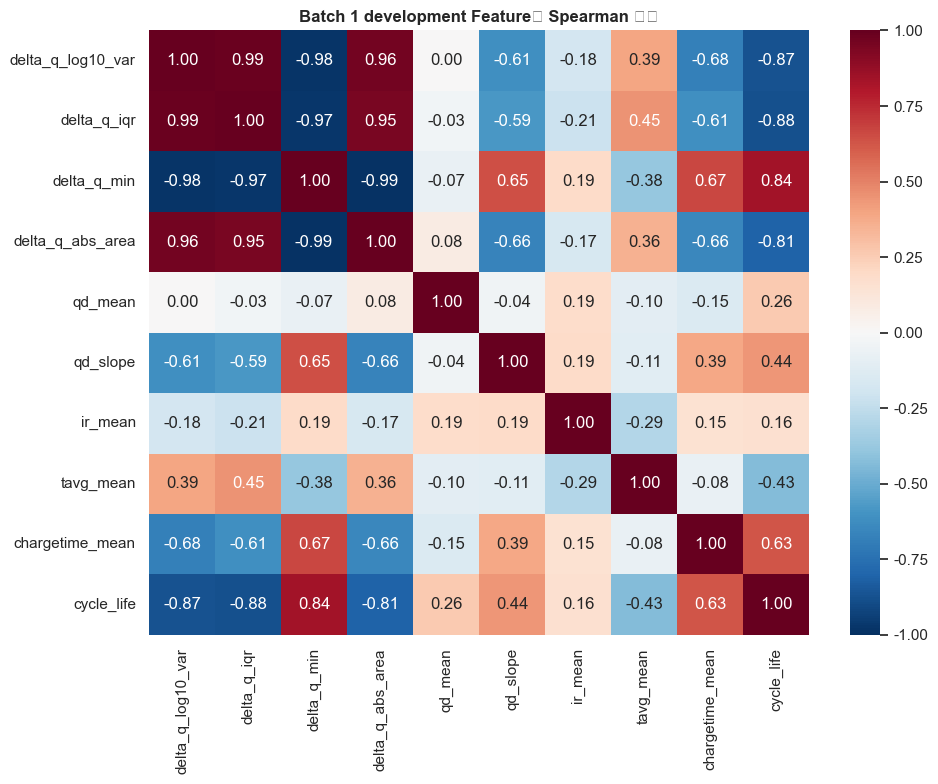

,Cycle Life와 Spearman ρ
delta_q_iqr,-0.8786
delta_q_log10_var,-0.8694
delta_q_min,0.8365
delta_q_abs_area,-0.8112
chargetime_mean,0.6262
qd_slope,0.4418
tavg_mean,-0.4321
qd_mean,0.2619
ir_mean,0.1586


In [11]:
development_ids = set(split_live.query("split == 'development'")["global_cell_id"])
development = feature_table[feature_table["global_cell_id"].isin(development_ids)].copy()
candidate_features = [
    "delta_q_log10_var", "delta_q_iqr", "delta_q_min", "delta_q_abs_area",
    "qd_mean", "qd_slope", "ir_mean", "tavg_mean", "chargetime_mean"
]
corr = development[candidate_features + ["cycle_life"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Batch 1 development Feature의 Spearman 상관", fontweight="bold")
plt.tight_layout(); plt.show()
display(corr["cycle_life"].drop("cycle_life").sort_values(key=abs, ascending=False).to_frame("Cycle Life와 Spearman ρ"))

상관은 후보를 이해하는 근거이지 최종 선택 기준 하나로 사용하지 않는다. 실제 선정은 같은 반복 CV에서 예측오차를 비교한다.

## 9. 누수 방지 자동검사

In [12]:
forbidden = ("cycle_life", "knee", "eol", "target", "observed_end", "global_cell_id", "cell_index", "batch")
candidate_names = manifest["feature_name"].tolist()
checks = {
    "Cell당 1행": feature_table["global_cell_id"].is_unique,
    "139개 원본 Cell": len(feature_table) == 139,
    "cycle 10·100 기반 ΔQ": set(manifest.loc[manifest["feature_name"].str.startswith("delta_q"), "cycle_range"]) == {"10,100"},
    "금지 Feature 없음": not any(token in name.lower() for name in candidate_names for token in forbidden),
    "Batch 1 split 고정": (split_live["split"] == "development").sum() == 36 and (split_live["split"] == "holdout").sum() == 10,
    "외부 Batch 선택 격리": set(split_live.query("batch != 'Batch 1' and target_available")["split"]) == {"external_test", "additional_test"},
}
display(pd.DataFrame([{"검사": key, "결과": "통과" if value else "실패"} for key, value in checks.items()]))
assert all(checks.values())

,검사,결과
0,Cell당 1행,통과
1,139개 원본 Cell,통과
2,cycle 10·100 기반 ΔQ,통과
3,금지 Feature 없음,통과
4,Batch 1 split 고정,통과
5,외부 Batch 선택 격리,통과


## 10. Feature Engineering 결론

- 원본 역참조부터 Cell당 1행 생성까지의 코드가 모두 포함되어 있다.
- 실제 cycle 2~100만 Summary Feature에 사용하고 ΔQ는 실제 cycle 10과 100으로 계산한다.
- Target 결측과 Feature 실패를 구분하고 모든 제외 이유를 기록한다.
- ΔQ 후보의 중복을 확인했으므로 대표값은 하나만 선택한다.
- Batch 1 development/hold-out을 고정했고 Batch 2·3은 선택 과정에서 격리했다.

다음 `03_modeling.ipynb`에서 ΔQ screening, F0~F4 Ablation, 다섯 모델의 반복 CV, 1-SE 선택, hold-out과 외부 Batch 평가를 실제 코드로 수행한다.

## 11. 추가 개선 실험 — 새로운 정보 표현

공식 v1 결과를 변경하지 않고 다음 세 표현을 별도 `day2_v2` 산출물로 생성했다.

1. 원 논문형 초기 Feature: cycle 2·100 용량, 최대용량 변화와 발생 cycle, 선형 기울기·절편, cycle 2~6 충전시간, 내부저항 변화
2. `ΔQ100-10(V)`의 공통 2.0~3.5V, 1,000-point 원곡선
3. cycle 20~100의 다중 ΔQ trajectory

모든 입력은 실제 cycle 100 이하만 사용한다. 아래 셀은 원본 역참조부터 새 Feature 생성까지의 실제 구현이다.

In [13]:
V2_RESULT_DIR = ROOT / "results" / "day2_v2"
COMMON_VOLTAGE = np.linspace(2.0, 3.5, 1000)
TRAJECTORY_CYCLES = tuple(range(20, 101, 10))

In [14]:
def value_at_cycle(cycles: np.ndarray, values: np.ndarray, cycle: int, metric: str) -> float:
    mask = np.isfinite(cycles) & np.isclose(cycles, cycle) & valid_metric_mask(metric, values)
    return float(values[np.flatnonzero(mask)[0]]) if mask.any() else np.nan

def window_mean(
    cycles: np.ndarray,
    values: np.ndarray,
    start: int,
    end: int,
    metric: str,
) -> float:
    mask = (cycles >= start) & (cycles <= end) & valid_metric_mask(metric, values)
    return float(np.mean(values[mask])) if mask.any() else np.nan

def interpolate_curve(voltage: np.ndarray, capacity: np.ndarray) -> np.ndarray:
    mask = np.isfinite(voltage) & np.isfinite(capacity)
    if mask.sum() < 20:
        return np.full(COMMON_VOLTAGE.shape, np.nan)
    v, q = voltage[mask], capacity[mask]
    order = np.argsort(v)
    v, q = v[order], q[order]
    unique_v, unique_idx = np.unique(v, return_index=True)
    q = q[unique_idx]
    result = np.interp(COMMON_VOLTAGE, unique_v, q, left=np.nan, right=np.nan)
    return result

def curve_statistics(prefix: str, curve: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(curve)
    if mask.sum() < 20:
        return {
            f"{prefix}_log10_var": np.nan,
            f"{prefix}_iqr": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_abs_area": np.nan,
            f"{prefix}_l2": np.nan,
        }
    values = curve[mask]
    voltage = COMMON_VOLTAGE[mask]
    variance = float(np.var(values, ddof=1))
    return {
        f"{prefix}_log10_var": float(np.log10(variance + 1e-12)),
        f"{prefix}_iqr": float(np.quantile(values, 0.75) - np.quantile(values, 0.25)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_abs_area": float(np.trapezoid(np.abs(values), voltage)),
        f"{prefix}_l2": float(np.sqrt(np.mean(np.square(values)))),
    }

def extract_v2_features() -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Extract paper-like scalars and multi-cycle ΔQ curves from raw files."""
    rows: list[dict[str, Any]] = []
    curve100_rows: list[np.ndarray] = []
    trajectory_rows: list[np.ndarray] = []

    metric_fields = {
        "qd": "QDischarge",
        "ir": "IR",
        "tavg": "Tavg",
        "tmax": "Tmax",
        "chargetime": "chargetime",
    }

    for batch_name, filename in BATCH_FILES.items():
        print(f"[v2 Feature] {batch_name}: {filename}", flush=True)
        with h5py.File(ROOT / "data" / filename, "r") as handle:
            batch = handle["batch"]
            n_cells = int(batch["cycle_life"].shape[0])
            for cell_index in range(n_cells):
                global_id = f"{batch_name.replace(' ', '')}_{cell_index:03d}"
                summary = handle[batch["summary"][cell_index, 0]]
                cycles = flat(summary["cycle"])
                arrays = {name: flat(summary[field]) for name, field in metric_fields.items()}
                common_length = min([len(cycles), *[len(v) for v in arrays.values()]])
                cycles = cycles[:common_length]
                arrays = {name: value[:common_length] for name, value in arrays.items()}

                qd = arrays["qd"]
                qd_mask = (cycles >= 2) & (cycles <= 100) & valid_metric_mask("qd", qd)
                qd_x, qd_y = cycles[qd_mask], qd[qd_mask]
                qd_cycle2 = value_at_cycle(cycles, qd, 2, "qd")
                if len(qd_y):
                    qd_max_index = int(np.argmax(qd_y))
                    qd_max = float(qd_y[qd_max_index])
                    qd_max_cycle = float(qd_x[qd_max_index])
                else:
                    qd_max, qd_max_cycle = np.nan, np.nan
                if len(qd_y) >= 3:
                    qd_slope, qd_intercept = np.polyfit(qd_x, qd_y, 1)
                else:
                    qd_slope, qd_intercept = np.nan, np.nan

                ir_cycle2 = value_at_cycle(cycles, arrays["ir"], 2, "ir")
                ir_cycle100 = value_at_cycle(cycles, arrays["ir"], 100, "ir")
                policy = decode_matlab_char(handle[batch["policy_readable"][cell_index, 0]])
                policy_info = parse_policy(policy)
                record: dict[str, Any] = {
                    "batch": batch_name,
                    "cell_index": cell_index,
                    "global_cell_id": global_id,
                    "cycle_life": deref_scalar(handle, batch["cycle_life"][cell_index, 0]),
                    "qd_cycle2": qd_cycle2,
                    "qd_cycle100": value_at_cycle(cycles, qd, 100, "qd"),
                    "qd_max_minus_cycle2": qd_max - qd_cycle2,
                    "qd_max_cycle": qd_max_cycle,
                    "qd_linear_slope_2_100": float(qd_slope),
                    "qd_linear_intercept_2_100": float(qd_intercept),
                    "qd_slope_95_100": (
                        float(np.polyfit(cycles[(cycles >= 95) & (cycles <= 100) & valid_metric_mask("qd", qd)],
                                         qd[(cycles >= 95) & (cycles <= 100) & valid_metric_mask("qd", qd)], 1)[0])
                        if ((cycles >= 95) & (cycles <= 100) & valid_metric_mask("qd", qd)).sum() >= 3
                        else np.nan
                    ),
                    "charge_time_mean_2_6": window_mean(cycles, arrays["chargetime"], 2, 6, "chargetime"),
                    "ir_min_2_100": (
                        float(np.min(arrays["ir"][(cycles >= 2) & (cycles <= 100) & valid_metric_mask("ir", arrays["ir"])]))
                        if ((cycles >= 2) & (cycles <= 100) & valid_metric_mask("ir", arrays["ir"])).any()
                        else np.nan
                    ),
                    "ir_cycle100_minus_cycle2": ir_cycle100 - ir_cycle2,
                    "tavg_mean_2_100": window_mean(cycles, arrays["tavg"], 2, 100, "tavg"),
                    "tmax_mean_2_100": window_mean(cycles, arrays["tmax"], 2, 100, "tmax"),
                    **policy_info,
                }

                cycle_to_index = {
                    int(round(cycle)): idx for idx, cycle in enumerate(cycles) if np.isfinite(cycle)
                }
                curves = handle[batch["cycles"][cell_index, 0]]["Qdlin"]
                voltage = flat(handle[batch["Vdlin"][cell_index, 0]])
                interpolated: dict[int, np.ndarray] = {}
                for target_cycle in (10, *TRAJECTORY_CYCLES):
                    idx = cycle_to_index.get(target_cycle)
                    if idx is None or idx >= curves.shape[0]:
                        interpolated[target_cycle] = np.full(COMMON_VOLTAGE.shape, np.nan)
                        continue
                    raw = np.asarray(handle[curves[idx, 0]]).reshape(-1)
                    if raw.dtype.kind != "f" or len(raw) != len(voltage):
                        interpolated[target_cycle] = np.full(COMMON_VOLTAGE.shape, np.nan)
                    else:
                        interpolated[target_cycle] = interpolate_curve(voltage, raw.astype(float))

                base_curve = interpolated[10]
                trajectory_curves = []
                for target_cycle in TRAJECTORY_CYCLES:
                    delta = interpolated[target_cycle] - base_curve
                    record.update(curve_statistics(f"dq{target_cycle}_10", delta))
                    trajectory_curves.append(delta)
                curve100_rows.append(trajectory_curves[-1])
                trajectory_rows.append(np.concatenate(trajectory_curves))
                rows.append(record)

    features = pd.DataFrame(rows)
    curve100 = np.vstack(curve100_rows)
    trajectory = np.vstack(trajectory_rows)
    if not features["global_cell_id"].is_unique:
        raise AssertionError("v2 global_cell_id가 유일하지 않습니다.")
    return features, curve100, trajectory

In [15]:
RUN_V2_RAW_EXTRACTION = False

if RUN_V2_RAW_EXTRACTION:
    v2_features_live, delta_q_curve_live, delta_q_trajectory_live = extract_v2_features()
    print("재추출:", v2_features_live.shape, delta_q_curve_live.shape, delta_q_trajectory_live.shape)
else:
    v2_features_live = pd.read_csv(V2_RESULT_DIR / "extended_feature_table.csv")
    curve_data = np.load(V2_RESULT_DIR / "delta_q_curve_data.npz", allow_pickle=False)
    delta_q_curve_live = curve_data["cycle100_minus10"]
    delta_q_trajectory_live = curve_data["trajectory"]

v2_manifest = pd.read_csv(V2_RESULT_DIR / "v2_feature_manifest.csv")

display(v2_features_live[[
    "global_cell_id", "batch", "cycle_life", "qd_cycle2", "qd_cycle100",
    "qd_max_minus_cycle2", "qd_max_cycle", "charge_time_mean_2_6",
    "ir_cycle100_minus_cycle2", "dq100_10_log10_var"
]].head())
print("ΔQ100-10 원곡선:", delta_q_curve_live.shape)
print("9개 다중 Cycle ΔQ 원곡선:", delta_q_trajectory_live.shape)
display(v2_manifest)
assert delta_q_curve_live.shape == (139, 1000)
assert delta_q_trajectory_live.shape == (139, 9000)

,global_cell_id,batch,cycle_life,qd_cycle2,qd_cycle100,qd_max_minus_cycle2,qd_max_cycle,charge_time_mean_2_6,ir_cycle100_minus_cycle2,dq100_10_log10_var
0,Batch1_000,Batch 1,"1,190.0000",1.0707,1.0759,0.4684,12.0000,13.3749,-0.0001,-5.0144
1,Batch1_001,Batch 1,"1,179.0000",1.0753,1.0806,0.0093,12.0000,13.4092,-0.0000,-5.0135
2,Batch1_002,Batch 1,"1,177.0000",1.0799,1.0849,0.0081,12.0000,13.3582,-0.0000,-4.7366
3,Batch1_003,Batch 1,"1,226.0000",1.0797,1.0847,0.0065,68.0000,12.0251,0.0000,-4.4422
4,Batch1_004,Batch 1,"1,227.0000",1.0784,1.0826,0.0059,68.0000,12.0419,-0.0001,-4.6473


ΔQ100-10 원곡선: (139, 1000)
9개 다중 Cycle ΔQ 원곡선: (139, 9000)


,feature_name,feature_family,source_field,cycle_range,formula,unit,missing_rule,transform_rule,leakage_check,official_v1_replacement
0,qd_cycle2,원 논문형 용량,summary.QDischarge,2,QD at actual cycle 2,Ah,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
1,qd_cycle100,원 논문형 용량,summary.QDischarge,100,QD at actual cycle 100,Ah,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
2,qd_max_minus_cycle2,원 논문형 용량,summary.QDischarge,2~100,max(QD)-QD(cycle 2),Ah,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
3,qd_max_cycle,원 논문형 용량,summary.QDischarge,2~100,argmax cycle of QD,cycle,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
4,qd_linear_slope_2_100,원 논문형 용량,summary.QDischarge,2~100,OLS slope of QD~cycle,Ah/cycle,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
5,qd_linear_intercept_2_100,원 논문형 용량,summary.QDischarge,2~100,OLS intercept of QD~cycle,Ah,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
6,qd_slope_95_100,후기 초기구간 용량,summary.QDischarge,95~100,OLS slope of QD~cycle,Ah/cycle,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
7,charge_time_mean_2_6,충전시간,summary.chargetime,2~6,mean(valid charge time),min,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
8,ir_min_2_100,내부저항,summary.IR,2~100,min(valid IR),ohm,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False
9,ir_cycle100_minus_cycle2,내부저항,summary.IR,"2,100",IR(100)-IR(2),ohm,각 CV train fold의 median imputation,Scaler/PCA/PLS를 Pipeline 안에서 fold train에만 fit,실제 cycle 번호 100 이하,False


이 확장은 Feature 수를 무작정 늘리는 작업이 아니다. 기존 `delta_q_iqr`가 버리던 전압 위치 정보를 보존하고, 원 논문과 현재 구현의 차이를 검증하기 위한 제한된 추가 실험이다. 모델 선택에는 계속 Batch 1 development만 사용한다.